In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path
from IPython.display import display

In [1]:
file_path = "/content/data_v3.zip"
file_output = "/content"

!unzip {file_path} -d {file_output}

Archive:  /content/data_v3.zip
 extracting: /content/data_v3/antibodies.csv  
 extracting: /content/data_v3/bal.csv  
 extracting: /content/data_v3/demographics.csv  
 extracting: /content/data_v3/lab_report.csv  
 extracting: /content/data_v3/libraries.csv  
 extracting: /content/data_v3/medications.csv  
 extracting: /content/data_v3/mrss.csv  
 extracting: /content/data_v3/pft.csv  
 extracting: /content/data_v3/skin_biopsies.csv  
 extracting: /content/data_v3/ssc_subtype.csv  
 extracting: /content/data_v3/vitals.csv  


In [9]:
# Path to folder containing CSV files
data_folder = Path("/content/data_v3")

# Store datasets
datasets = {}

# Function to clean column names
def clean_columns(df):
    df.columns = (
        df.columns
        .astype(str)
        .str.strip()
        .str.lower()
        .str.replace(r"[^\w]+", "_", regex=True)
        .str.replace(r"_+", "_", regex=True)
        .str.strip("_")
    )
    return df


# Read and process each CSV
for file in data_folder.glob("*.csv"):

    name = file.stem

    # Read CSV
    df = pd.read_csv(file)

    # Clean columns
    df = clean_columns(df)

    # Store dataframe
    datasets[name] = df

    print("=" * 80)
    print(f"Dataset: {name}")
    print(f"Rows: {df.shape[0]:,}")
    print(f"Columns: {df.shape[1]}")

    # Create column summary table
    column_info = pd.DataFrame({
        "Column": df.columns,
        "Data Type": df.dtypes.astype(str).values,
        "Missing Values": df.isna().sum().values,
        "Duplicate Values": [
          df[col].duplicated().sum()
          for col in df.columns
      ],
        "Duplicate (%)": [
        round((df[col].duplicated().sum() / len(df)) * 100, 2)
        for col in df.columns
    ]
  })
    display(column_info)

Dataset: demographics
Rows: 1,500
Columns: 12


,Column,Data Type,Missing Values,Duplicate Values,Duplicate (%)
0,study,object,0,1499,99.93
1,case_number,object,0,0,0.00
2,first_name,object,0,1157,77.13
3,last_name,object,0,1188,79.20
4,birth_date,object,0,66,4.40
5,ethnicity,object,0,1498,99.87
6,gender,object,0,1498,99.87
7,races,object,0,1496,99.73
8,diagnosis,object,0,1499,99.93
9,state,object,0,1492,99.47


Dataset: antibodies
Rows: 3,511
Columns: 4


,Column,Data Type,Missing Values,Duplicate Values,Duplicate (%)
0,case_number,object,0,2080,59.24
1,dts,object,0,1558,44.37
2,test,object,0,3508,99.91
3,value,object,0,3507,99.89


Dataset: mrss
Rows: 3,113
Columns: 4


...

,Column,Data Type,Missing Values,Duplicate Values,Duplicate (%)
0,reg_id,object,0,29628,95.76
1,order_date,object,5,28923,93.48
2,component_name,object,0,30921,99.94
3,value,object,588,28988,93.69


Dataset: libraries
Rows: 918
Columns: 24


,Column,Data Type,Missing Values,Duplicate Values,Duplicate (%)
0,reg_id,object,0,216,23.53
1,cell_viability,float64,78,454,49.46
2,processing_date,object,546,574,62.53
3,comment,object,740,906,98.69
4,rna_isolation_kit,object,647,914,99.56
5,kit_lot_number,float64,647,909,99.02
6,elution_vol_ul,float64,647,912,99.35
7,macrophage_rna_tube_id,float64,671,670,72.98
8,macrophage_rna_tube_location_box_id,object,671,909,99.02
9,date_of_rna_qc,object,725,731,79.63


Dataset: skin_biopsies
Rows: 215
Columns: 8


,Column,Data Type,Missing Values,Duplicate Values,Duplicate (%)
0,case_number,object,0,65,30.23
1,biopsy_date,object,0,6,2.79
2,entry_user_name,object,0,196,91.16
3,biopsy_site,object,0,206,95.81
4,clinical_indication,object,0,210,97.67
5,specimen_accession,object,0,0,0.00
6,image_file_path,object,0,0,0.00
7,image_format,object,0,213,99.07


In [10]:
# Pivot selected long-format tables into wide format

# Retrieve tables from the datasets dictionary
pft = datasets["pft"].copy()
vitals = datasets["vitals"].copy()
lab_report = datasets["lab_report"].copy()

# ------------------------------------------------------------
# 1. Pulmonary Function Tests (PFT)

pft_wide = (
    pft.pivot_table(
        index=["case_number", "pft_dts"],
        columns="name",
        values="ord_value",
        aggfunc="first"
    )
    .reset_index()
)
pft_wide = clean_columns(pft_wide)

# ------------------------------------------------------------
# 2. Vitals

vitals_wide = (
    vitals.pivot_table(
        index=["reg_id", "date"],
        columns="vital_type_name_category",
        values="vital_value",
        aggfunc="first"
    )
    .reset_index()
)
vitals_wide = clean_columns(vitals_wide)

print("=" * 80)

# ------------------------------------------------------------
# 3. Lab Reports

lab_report["value"] = pd.to_numeric(
    lab_report["value"],
    errors="coerce"
)

lab_report_wide = (
    lab_report.pivot_table(
        index=["reg_id", "order_date"],
        columns="component_name",
        values="value",
        aggfunc="first"
    )
    .reset_index()
)
lab_report_wide = clean_columns(lab_report_wide)

print("=" * 80)

# ------------------------------------------------------------
# Summary
from IPython.display import display, Markdown

pivoted_tables = {
    "PFT": pft_wide,
    "Vitals": vitals_wide,
    "Lab Reports": lab_report_wide
}
for name, df in pivoted_tables.items():

    print("=" * 80)
    print(f"{name} Dataset")
    print(f"Rows: {df.shape[0]:,}")
    print(f"Columns: {df.shape[1]}")

    # Create quality summary table
    summary = pd.DataFrame({
        "Column": df.columns,
        "Data Type": df.dtypes.astype(str).values,
        "Missing Values": df.isna().sum().values,
        "Missing (%)": (
            (df.isna().mean() * 100)
            .round(2)
            .values
        ),
        "Duplicate Values": [
            df[col].duplicated().sum()
            for col in df.columns
        ],
        "Duplicate (%)": [
            round(
                (df[col].duplicated().sum() / len(df)) * 100,
                2
            )
            for col in df.columns
        ]
    })

    display(summary.style.hide(axis="index"))

PFT Dataset
Rows: 1,723
Columns: 5


Column,Data Type,Missing Values,Missing (%),Duplicate Values,Duplicate (%)
case_number,object,0,0.000000,549,31.860000
pft_dts,object,0,0.000000,515,29.890000
dlco_sb,float64,894,51.890000,1295,75.160000
fev1,float64,0,0.000000,1132,65.700000
fvc,float64,0,0.000000,1113,64.600000


Vitals Dataset
Rows: 9,131
Columns: 7


Column,Data Type,Missing Values,Missing (%),Duplicate Values,Duplicate (%)
reg_id,object,0,0.000000,7628,83.540000
date,object,0,0.000000,6084,66.630000
bmi,float64,1354,14.830000,8833,96.740000
bp_diastolic,float64,1283,14.050000,9085,99.500000
bp_systolic,float64,1283,14.050000,9065,99.280000
pulse,float64,750,8.210000,9071,99.340000
weight_in_pound,float64,735,8.050000,8000,87.610000


Lab Reports Dataset
Rows: 3,264
Columns: 21


Column,Data Type,Missing Values,Missing (%),Duplicate Values,Duplicate (%)
reg_id,object,0,0.000000,1951,59.770000
order_date,object,0,0.000000,1247,38.200000
absolute_basophils,float64,1907,58.430000,3248,99.510000
absolute_eosinophils,float64,1873,57.380000,3201,98.070000
absolute_lymphocytes,float64,1942,59.500000,2949,90.350000
absolute_monocyte,float64,1865,57.140000,3152,96.570000
basophils,float64,1902,58.270000,3246,99.450000
eosinophils,float64,1898,58.150000,3197,97.950000
hematocrit,float64,1350,41.360000,3029,92.800000
hemoglobin,float64,1349,41.330000,3182,97.490000


In [37]:

# ============================================================
# Generate Relationship Summary Table
# ============================================================

relationships = []

tables = list(datasets.keys())

for i in range(len(tables)):
    for j in range(i + 1, len(tables)):

        table1 = tables[i]
        table2 = tables[j]

        df1 = datasets[table1]
        df2 = datasets[table2]

        # Find common columns
        common_cols = set(df1.columns).intersection(df2.columns)

        for col in common_cols:

            # Focus on identifier columns
            if (
                "id" in col.lower()
                or "case" in col.lower()
                or "number" in col.lower()
            ):

                # Determine relationship type
                table1_unique = df1[col].is_unique
                table2_unique = df2[col].is_unique

                if table1_unique and table2_unique:
                    relationship = "One-to-One"

                elif table1_unique and not table2_unique:
                    relationship = "One-to-Many"

                elif not table1_unique and table2_unique:
                    relationship = "One-to-Many"

                else:
                    relationship = "Many-to-Many"

                relationships.append({
                    "Table 1": table1,
                    "Table 2": table2,
                    "Relationship Key": col,
                    "Relationship Type": relationship
                })


# Create summary dataframe
relationship_summary = pd.DataFrame(relationships)

# Remove duplicate relationships if any
relationship_summary = relationship_summary.drop_duplicates()

display(relationship_summary)

,Table 1,Table 2,Relationship Key,Relationship Type
0,demographics,antibodies,case_number,One-to-Many
1,demographics,pft,case_number,One-to-Many
2,demographics,skin_biopsies,case_number,One-to-Many
3,antibodies,pft,case_number,Many-to-Many
4,antibodies,skin_biopsies,case_number,Many-to-Many
5,mrss,bal,reg_id,Many-to-Many
6,mrss,medications,reg_id,Many-to-Many
7,mrss,vitals,reg_id,Many-to-Many
8,mrss,lab_report,reg_id,Many-to-Many
9,mrss,libraries,reg_id,Many-to-Many


In [14]:
# ERD interactive

**Visualisation**



In [11]:
# Change to common identifier

# Identify possible column names
id_columns = [
    "case_number",
    "study_code",
    "patient_id",
    "subject_id",
    "participant_id",
    "case_id",
    "record_id"
]

# Rename any matching identifier to reg_id
for name, df in datasets.items():
    rename_dict = {}

    for col in df.columns:
        if col.lower() in id_columns:
            rename_dict[col] = "reg_id"

    if rename_dict:
        df.rename(columns=rename_dict, inplace=True)
        print(f"{name}: {rename_dict}")


demographics: {'case_number': 'reg_id'}
antibodies: {'case_number': 'reg_id'}
pft: {'case_number': 'reg_id'}
ssc_subtype: {'study_code': 'reg_id'}
skin_biopsies: {'case_number': 'reg_id'}


In [12]:
output_folder = Path("cleaned_datasets")
output_folder.mkdir(exist_ok=True)

# Save original datasets
for name, df in datasets.items():
    df.to_csv(output_folder / f"{name}.csv", index=False)

# Save pivoted datasets
pft_wide.to_csv(output_folder / "pft_wide.csv", index=False)
vitals_wide.to_csv(output_folder / "vitals_wide.csv", index=False)
lab_report_wide.to_csv(output_folder / "lab_report_wide.csv", index=False)

print("All datasets saved successfully.")

All datasets saved successfully.


In [13]:
# Import new cleaned dataset
# Path to cleaned dataset folder
cleaned_folder = Path("cleaned_datasets")

# Dictionary to store cleaned datasets
cleaned_datasets = {}

# Load all CSV files
for file in cleaned_folder.glob("*.csv"):

    df = pd.read_csv(file)

    # Store using filename (without .csv) as key
    cleaned_datasets[file.stem] = df

print("Loaded datasets:")
print(cleaned_datasets.keys())

Loaded datasets:
dict_keys(['demographics', 'vitals_wide', 'antibodies', 'mrss', 'bal', 'medications', 'lab_report_wide', 'pft', 'vitals', 'ssc_subtype', 'lab_report', 'libraries', 'skin_biopsies', 'pft_wide'])


In [70]:
demographics = cleaned_datasets["demographics"]
antibodies = cleaned_datasets["antibodies"]
mrss = cleaned_datasets["mrss"]
bal = cleaned_datasets["bal"]
medications = cleaned_datasets["medications"]

pft_wide = cleaned_datasets["pft_wide"]
vitals_wide = cleaned_datasets["vitals_wide"]
lab_report_wide = cleaned_datasets["lab_report_wide"]

ssc_subtype = cleaned_datasets["ssc_subtype"]
skin_biopsies = cleaned_datasets["skin_biopsies"]
libraries = cleaned_datasets["libraries"]

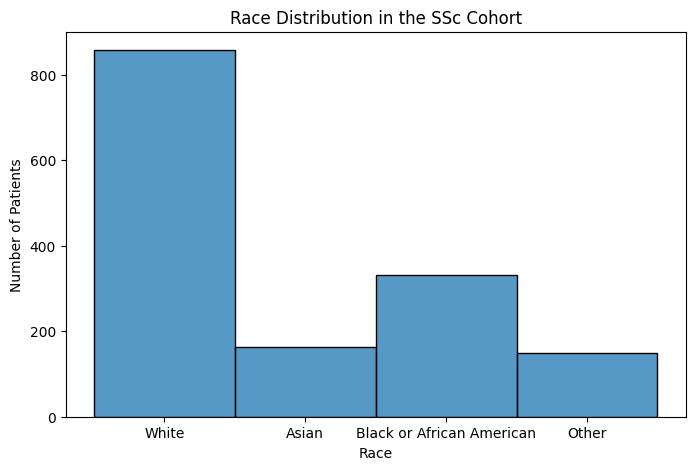

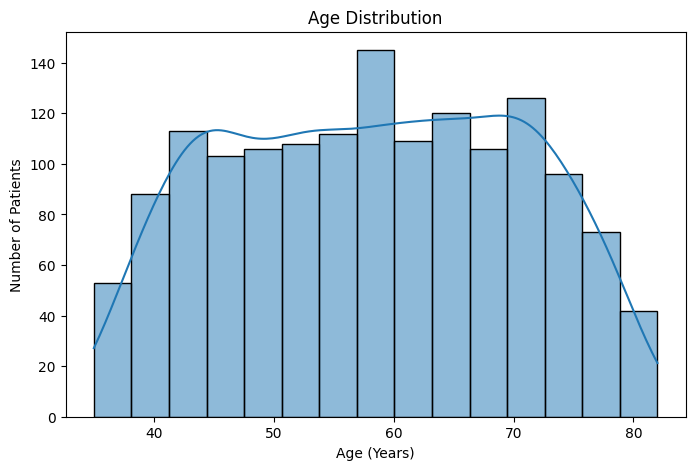

/tmp/ipykernel_721/1627306532.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


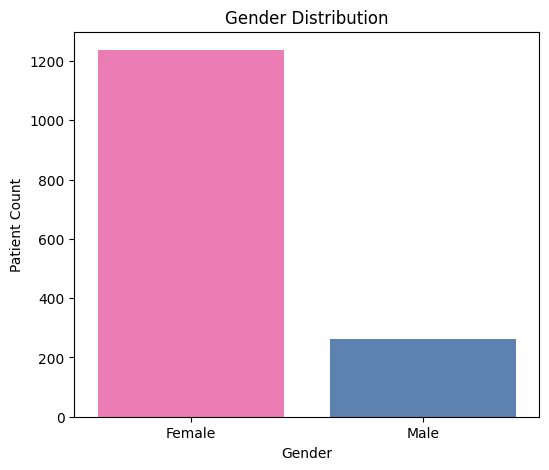

In [71]:
# 1. Demographics

# Race Distribution
plt.figure(figsize=(8,5))
sns.histplot(demographics["races"], bins=20, kde=False)
plt.title("Race Distribution in the SSc Cohort")
plt.xlabel("Race")
plt.ylabel("Number of Patients")
plt.show()

# Age distribution
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

demographics = datasets["demographics"].copy()

# Convert birth date
demographics["birth_date"] = pd.to_datetime(
    demographics["birth_date"],
    errors="coerce"
)

# Calculate age
today = pd.Timestamp.today()
demographics["age"] = (
    (today - demographics["birth_date"]).dt.days / 365.25
).astype(int)

plt.figure(figsize=(8,5))

sns.histplot(
    demographics["age"],
    bins=15,
    kde=True
)

plt.title("Age Distribution")
plt.xlabel("Age (Years)")
plt.ylabel("Number of Patients")

plt.show()

# Gender distribution
plt.figure(figsize=(6,5))
sns.countplot(
    data=demographics,
    x="gender",
    palette={
    "Female": "#FF69B4",  # Pink
    "Male": "#4F81BD"     # Blue
}
)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Patient Count")

plt.show()


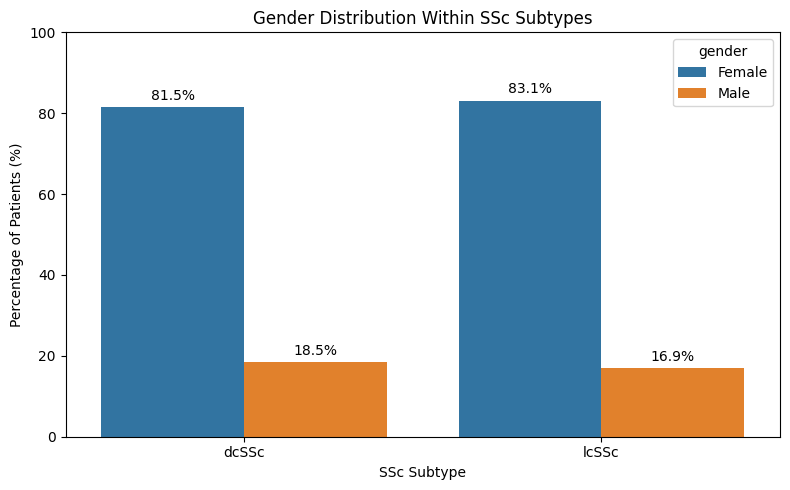

In [72]:
# Merge demographics with SSc subtype information
ssc_demo = demographics.merge(
    ssc_subtype,
    on="reg_id",
    how="left"
)

# Create gender count table
ssc_gender_pct = (
    ssc_demo
    .groupby(["ssc_subtype", "gender"])
    .size()
    .reset_index(name="count")
)

# Calculate percentage within each SSc subtype
ssc_gender_pct["percentage"] = (
    ssc_gender_pct.groupby("ssc_subtype")["count"]
    .transform(lambda x: x / x.sum() * 100)
)

# Plot
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=ssc_gender_pct,
    x="ssc_subtype",
    y="percentage",
    hue="gender"
)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

plt.title("Gender Distribution Within SSc Subtypes")
plt.xlabel("SSc Subtype")
plt.ylabel("Percentage of Patients (%)")

plt.ylim(0, 100)
plt.tight_layout()

plt.show()

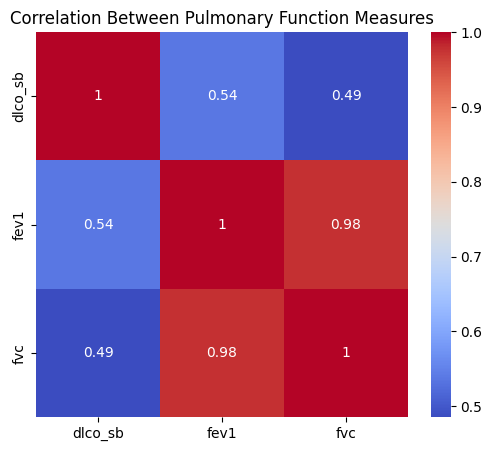

In [44]:
plt.figure(figsize=(6,5))

corr = pft_wide[
    ["dlco_sb", "fev1", "fvc"]
].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Between Pulmonary Function Measures")

plt.show()